In [58]:
# Import the required libraries

import numpy as np
import pandas as pd

import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# To use statsmodels for linear regression
import statsmodels.formula.api as smf

# To use sklearn for linear regression
from sklearn.linear_model import LinearRegression

In [59]:
end = dt.date.today()
print(end)

2026-03-24


In [60]:
start = end - dt.timedelta(days=365)

In [61]:
df = yf.download(['KO','SPY','PEP','USDX'], start=start, end=end)['Close']

/tmp/ipykernel_363/2596215543.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(['KO','SPY','PEP','USDX'], start=start, end=end)['Close']
[*********************100%***********************]  4 of 4 completed


In [62]:
df.columns = df.columns.str.lower()
returns = df.copy()

In [63]:
returns['ko'] = np.log(df['ko'] / df['ko'].shift(1))
returns['spy'] = np.log(df['spy'] / df['spy'].shift(1))
returns['pep'] = np.log(df['pep'] / df['pep'].shift(1))
returns['usdx'] = np.log(df['usdx'] / df['usdx'].shift(1))

In [64]:
returns.dropna(inplace=True)

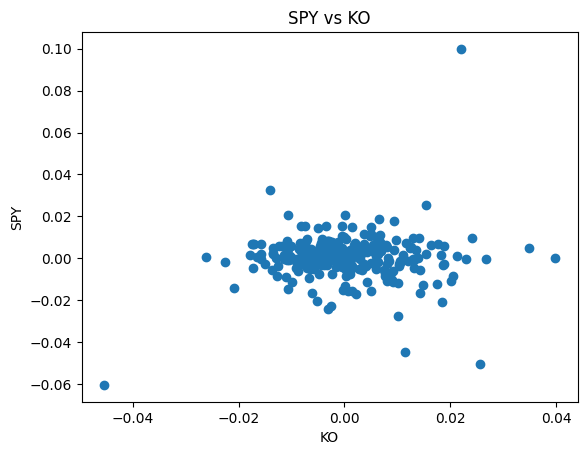

In [65]:
plt.scatter(returns['ko'], returns['spy'])
plt.xlabel('KO')
plt.ylabel('SPY')
plt.title('SPY vs KO')
plt.show()

In [66]:
corr = returns['ko'].corr(df['spy'])
print(corr)

0.033508193022087275


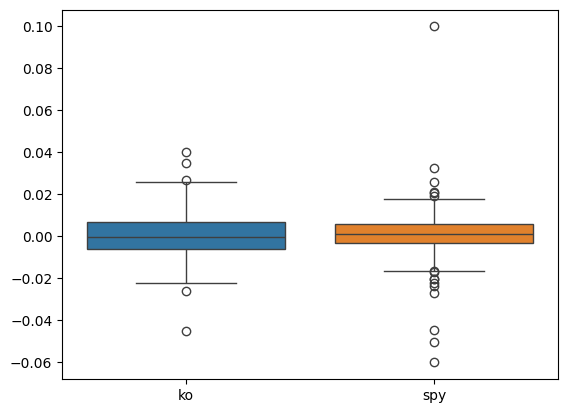

In [67]:
# Outlier Check
sns.boxplot(data=[returns['ko'], returns['spy']])
plt.show()

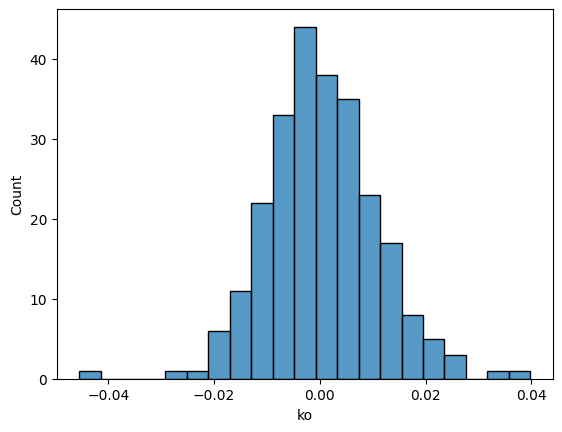

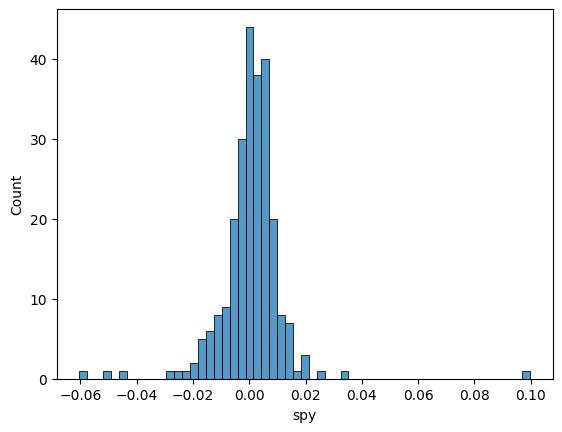

In [69]:
sns.histplot(returns['ko'])
plt.show()

sns.histplot(returns['spy'])
plt.show()